In [19]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_csv("../training/data/diabetes_prediction_dataset.csv")

In [2]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.shape

(100000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].value_counts())
    print("-"*50)

gender
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
--------------------------------------------------
smoking_history
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64
--------------------------------------------------


In [9]:
df.duplicated().sum()

np.int64(3854)

In [10]:
df.drop_duplicates(inplace=True)

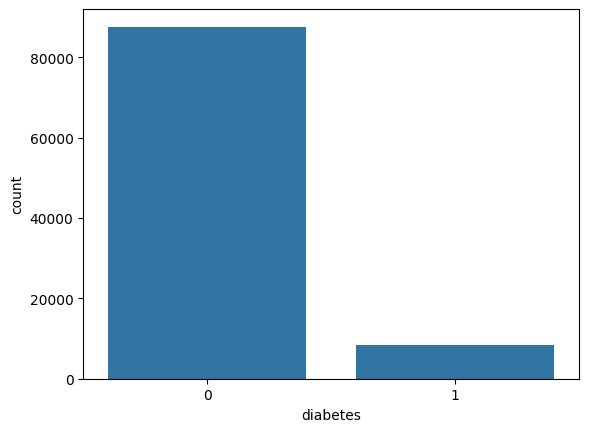

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="diabetes")
plt.show()

In [16]:
df["diabetes"].value_counts(normalize=True)

diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64

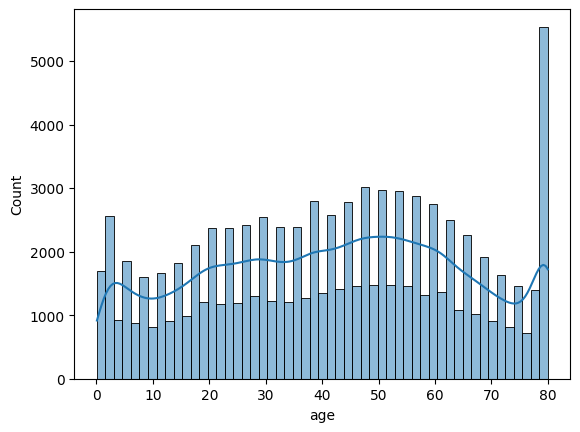

In [12]:
sns.histplot(df["age"], kde=True)
plt.show()

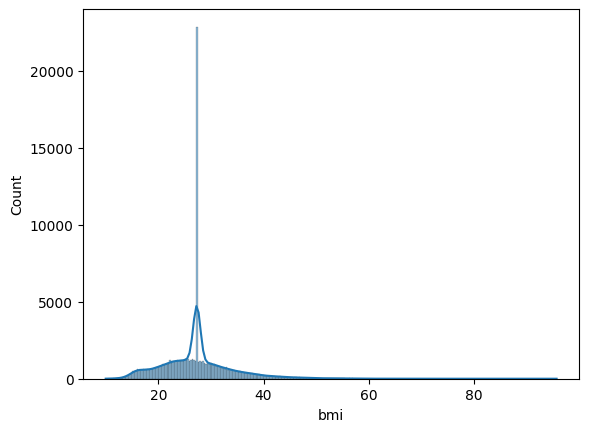

In [13]:
sns.histplot(df["bmi"], kde=True)
plt.show()

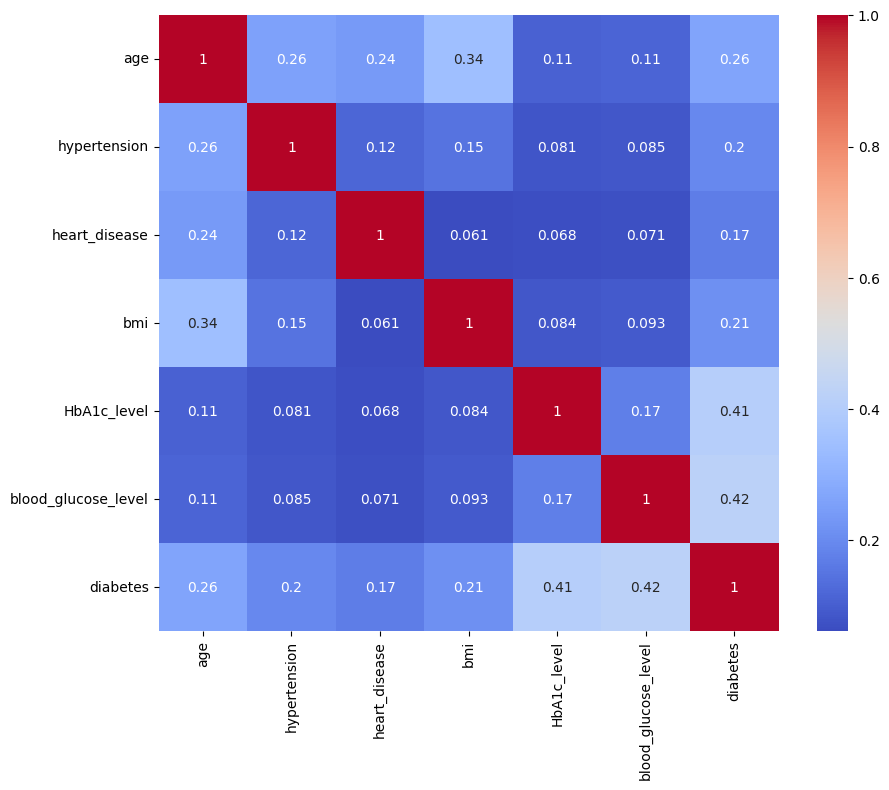

In [14]:
numeric_cols = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

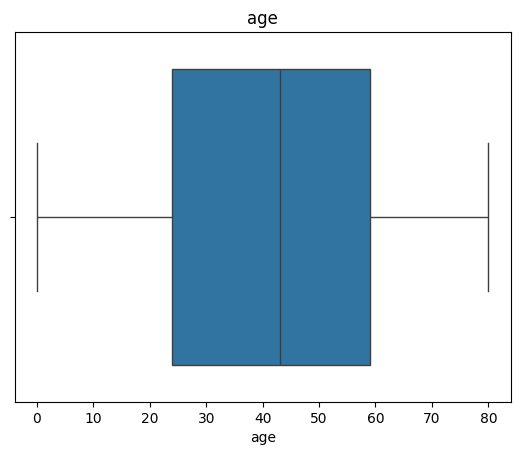

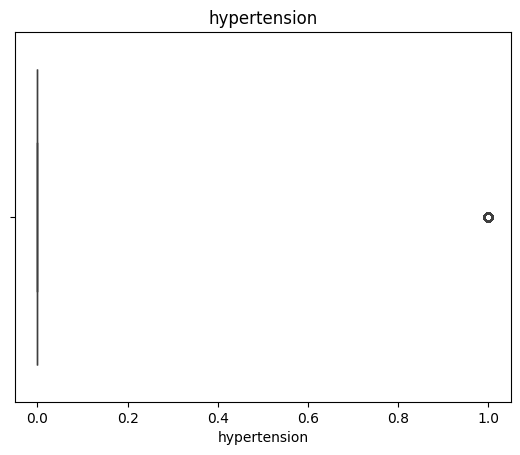

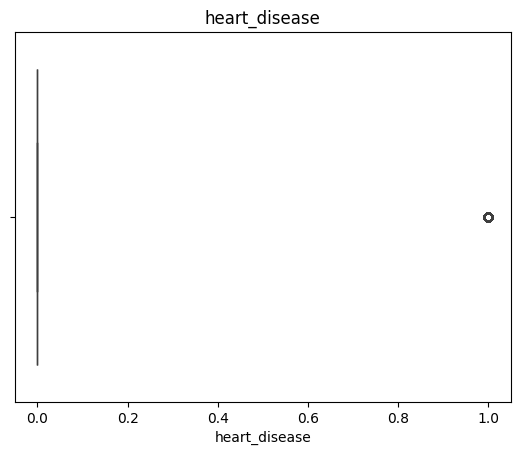

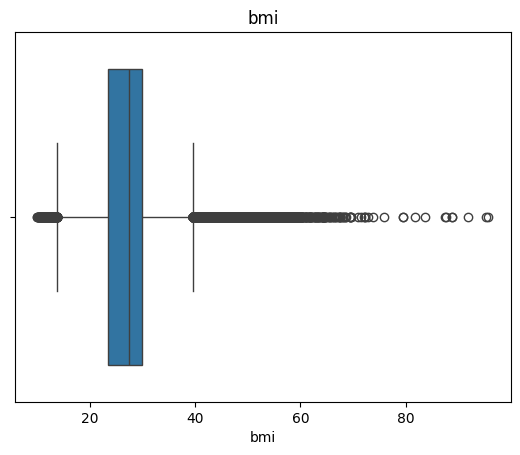

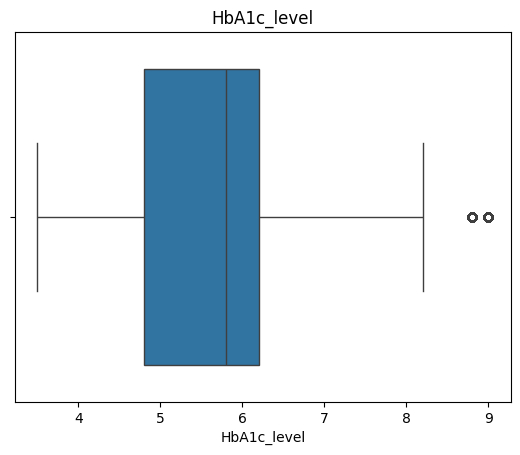

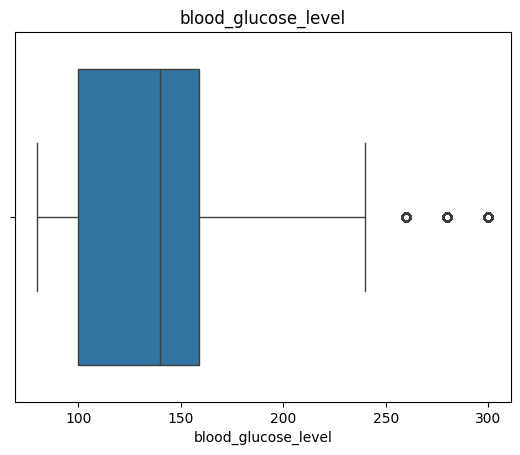

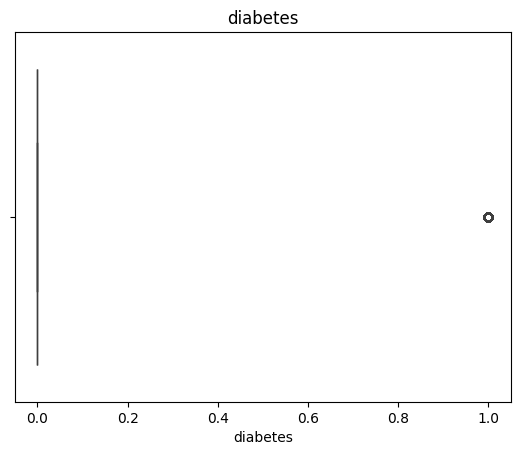

In [15]:
for col in numeric_cols.columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [20]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    print(col)
    print(df[col].describe())
    print("-"*50)

age
count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64
--------------------------------------------------
hypertension
count    100000.00000
mean          0.07485
std           0.26315
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max           1.00000
Name: hypertension, dtype: float64
--------------------------------------------------
heart_disease
count    100000.000000
mean          0.039420
std           0.194593
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: heart_disease, dtype: float64
--------------------------------------------------
bmi
count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max       

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00
